# Transfer Matrix Method (TTM) for DBR design

See `scrips/DBR.py` for all the functions.  
The rough method: track the fields (E,H) accross each layer of the DBRs.  
Each layer can be represented as a matrix. Ordered product of the matrix gives the propagation of the fields.  

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from DBR import *

### Parameters

In [ ]:
nm = 1e-9
lam0 = 650*nm # design wavelength

# these n are placeholders - see paper for exact values
# change them as function of lambda?    
n_air   = 1.00
n_GaN   = 2.38
n_InAlN = 2.10
n_SiO2  = 1.46
n_TiO2  = 2.45
n_out = n_air 
n_sub = n_GaN # maybe free standing should be like a layer? also maybe gold?

# number of periods in the DBRs - micropillar build
N_top = 20 # InAlN/GaN (low contrast - many periods)
N_bot = 8 # SiO2/TiO2 
n_cav = n_GaN

# for the scan
lam_min, lam_max, n_scan = 450*nm, 900*nm, 4000

### Individual DBRs stopbands

0.9888123593107632
0.9995750094587122


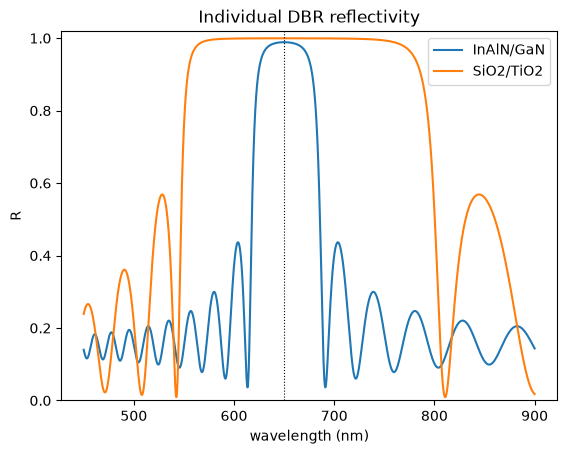

mirror          Δλ sim   Δλ formula
InAlN/GaN        46 nm        52 nm
SiO2/TiO2       222 nm       212 nm


In [10]:
lams = np.linspace(lam_min,lam_max,n_scan)
t = build_DBR(n_GaN, n_InAlN, N_top, lam0) # GaN faces air
b = build_DBR(n_TiO2, n_SiO2, N_bot, lam0)

plt.figure()
rows = []
for mirror,name,(nh,nl) in [(t,"InAlN/GaN",(n_GaN,n_InAlN)),(b,"SiO2/TiO2",(n_TiO2,n_SiO2))]:
    R, _ = sweep(mirror,n_out,n_sub,lams)
    lower,higher,width = stopband(lams,R,threshold=0.95)
    w_formula = (4/np.pi)*np.arcsin((nh-nl)/(nh+nl))*lam0 # standard analytical solution
    plt.plot(lams/nm,R,label=name)
    rows.append((name,width/nm,w_formula/nm))
    print(max(R))
plt.axvline(lam0/nm,color="k",lw=0.8,ls=":")
plt.xlabel("wavelength (nm)"); plt.ylabel("R"); plt.ylim(0,1.02)
plt.legend(); plt.title("Individual DBR reflectivity")
plt.show()

print(f"{'mirror':<12}{'Δλ sim':>10}{'Δλ formula':>13}")
for name,ws,wf in rows:
    print(f"{name:<12}{ws:>7.0f} nm{wf:>10.0f} nm")

### Full micropillar

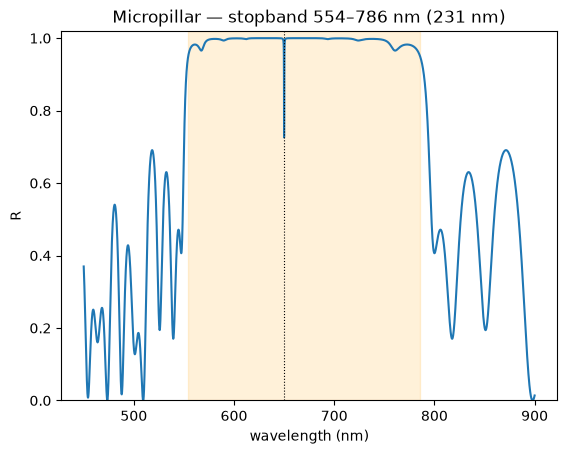

In [11]:
stack = build_microcavity(t,b,n_cav,lam0)
R, T = sweep(stack,n_out,n_sub,lams)
lower,higher,width = stopband(lams,R,threshold=0.95)

plt.figure()
plt.plot(lams/nm,R)
plt.axvspan(lower/nm,higher/nm,color="orange",alpha=0.15)
plt.axvline(lam0/nm,color="k",lw=0.8,ls=":")
plt.xlabel("wavelength (nm)"); plt.ylabel("R"); plt.ylim(0, 1.02)
plt.title(f"Micropillar — stopband {lower/nm:.0f}–{higher/nm:.0f} nm ({width/nm:.0f} nm)")
plt.show()

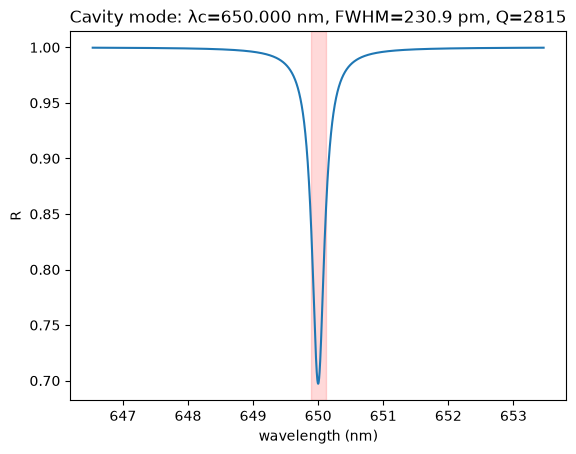

In [12]:
lam_c,fwhm,Q,Rmin = cavity_dip(stack,n_out,n_sub,lam0)

lz = np.linspace(lam_c-15*fwhm,lam_c+15*fwhm,3000)
Rz,_ = sweep(stack,n_out,n_sub,lz)

plt.figure()
plt.plot(lz/nm,Rz)
plt.axvspan((lam_c-fwhm/2)/nm,(lam_c+fwhm/2)/nm,color="red",alpha=0.15)
plt.xlabel("wavelength (nm)"); plt.ylabel("R")
plt.title(f"Cavity mode: λc={lam_c/nm:.3f} nm, FWHM={fwhm/nm*1000:.1f} pm, Q={Q:.0f}")
plt.show()

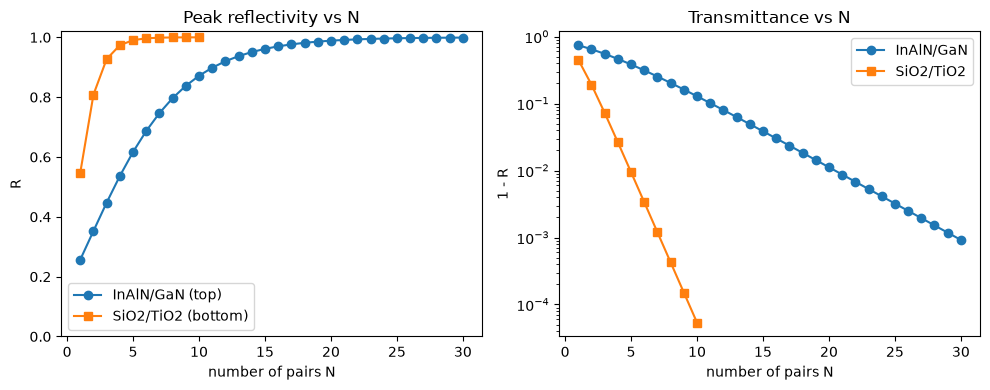

In [13]:
# reflectivity at lambda_0 vs N
Ns_top = np.arange(1,31) # InAlN/GaN
Ns_bot = np.arange(1,11) # SiO2/TiO2

R_top_of_N = np.array([reflectance(build_DBR(n_GaN,n_InAlN,N,lam0),
                                   n_out,n_sub,lam0)[0] for N in Ns_top])
R_bot_of_N = np.array([reflectance(build_DBR(n_TiO2,n_SiO2,N,lam0),
                                   n_out,n_sub,lam0)[0] for N in Ns_bot])

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10, 4))
ax1.plot(Ns_top,R_top_of_N,"o-",label="InAlN/GaN (top)")
ax1.plot(Ns_bot,R_bot_of_N,"s-",label="SiO2/TiO2 (bottom)")
ax1.set_xlabel("number of pairs N"); ax1.set_ylabel("R"); ax1.set_ylim(0,1.02)
ax1.legend(); ax1.set_title("Peak reflectivity vs N")

ax2.semilogy(Ns_top,1-R_top_of_N,"o-",label="InAlN/GaN")
ax2.semilogy(Ns_bot,1-R_bot_of_N,"s-",label="SiO2/TiO2")
ax2.set_xlabel("number of pairs N"); ax2.set_ylabel("1 - R")
ax2.legend(); ax2.set_title("Transmittance vs N")
plt.tight_layout(); plt.show()

N_bot= 1/10 done
N_bot= 2/10 done
N_bot= 3/10 done
N_bot= 4/10 done
N_bot= 5/10 done
N_bot= 6/10 done
N_bot= 7/10 done
N_bot= 8/10 done
N_bot= 9/10 done
N_bot=10/10 done


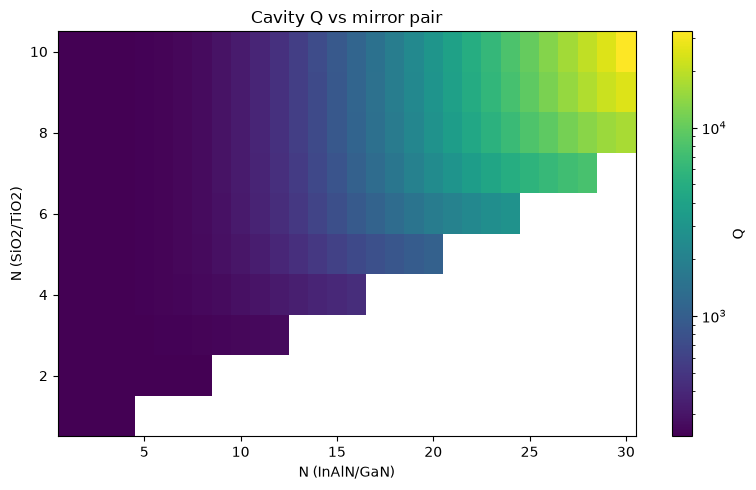

In [15]:
# heatmap of cavity Q vs (N_top, N_bot

Q_grid = np.empty((len(Ns_bot), len(Ns_top)))
for i,Nb in enumerate(Ns_bot):
    mirror_bot = build_DBR(n_TiO2,n_SiO2,Nb,lam0)
    for j,Nt in enumerate(Ns_top):
        mirror_top = build_DBR(n_GaN,n_InAlN,Nt,lam0)
        stack_ij = build_microcavity(mirror_top,mirror_bot,n_cav,lam0)
        _,_,Q_grid[i, j],_ = safe_cavity_dip(stack_ij,n_out,n_sub,lam0)
    print(f"N_bot={Nb:2d}/{Ns_bot[-1]} done")

valid = R_bot_of_N[:,None] > R_top_of_N[None,:]  # only when R_bottom > R_top
Q_grid_masked = np.ma.masked_where(~valid,Q_grid)

fig,ax = plt.subplots(figsize=(8,5))
pc = ax.pcolormesh(Ns_top,Ns_bot,Q_grid_masked,
                   norm=LogNorm(),shading="nearest",cmap="viridis")
fig.colorbar(pc,label="Q")
ax.set_xlabel("N (InAlN/GaN)"); ax.set_ylabel("N (SiO2/TiO2)")
ax.set_title("Cavity Q vs mirror pair")
plt.tight_layout(); plt.show()